In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/road-accident-united-kingdom-uk-dataset/UK_Accident.csv
/kaggle/input/road-traffic-accidents/RTA Dataset.csv
/kaggle/input/road-traffic-accidents/cleaned.csv
/kaggle/input/uk-accident-clean-csv/cleaned_dataset.csv


In [38]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score, mean_absolute_error, mean_squared_error
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score,f1_score,roc_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold # import KFold
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [ ]:

# Load the dataset
df = pd.read_csv(r"/kaggle/input/road-accident-united-kingdom-uk-dataset/UK_Accident.csv")
df

In [ ]:

# Load the dataset
dt = pd.read_csv(r"/kaggle/input/road-accident-united-kingdom-uk-dataset/UK_Accident.csv")
dt.head()

In [ ]:
print(dt.info())

In [ ]:
dt.isnull().sum()

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(dt)
plt.show()
msno.heatmap(dt)
plt.show()

In [ ]:
dt.shape

In [ ]:
#Remove duplicate rows
dt_no_duplicates = dt.drop_duplicates()
dt_no_duplicates.duplicated().sum()

In [ ]:
# Identify categorical columns
categorical_cols = dt.select_dtypes(include=['object']).columns

# Print categorical columns
print("Categorical Columns:")
print(categorical_cols)


In [ ]:
from sklearn.preprocessing import LabelEncoder
# Apply label encoding to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    dt[col] = le.fit_transform(dt[col])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
correlation_matrix = dt.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
class_count = dt["Accident_Severity"].value_counts()
class_count

In [ ]:
dt.head()

# RTA Dataset using

In [39]:
# Load the dataset
df = pd.read_csv(r"/kaggle/input/road-traffic-accidents/RTA Dataset.csv")
df

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


In [43]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [42]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                

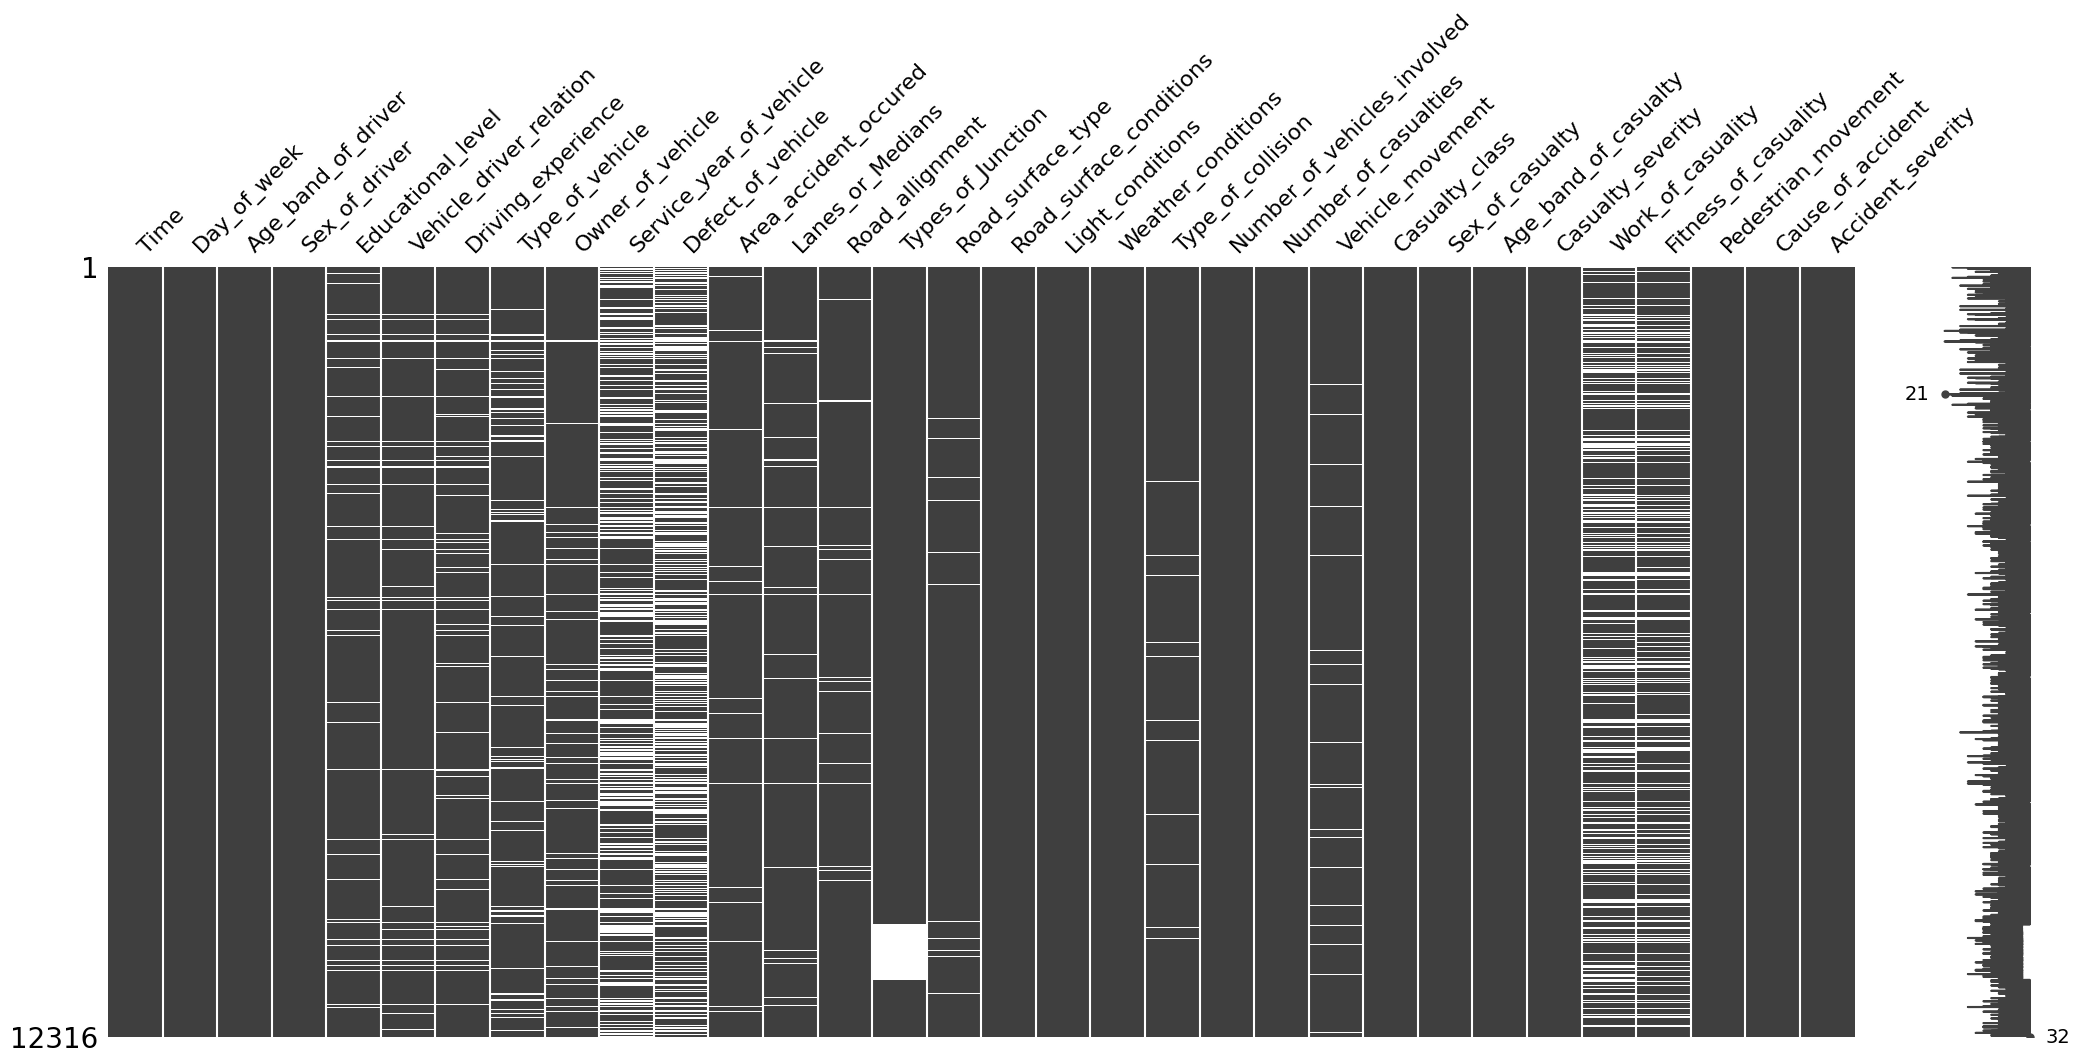

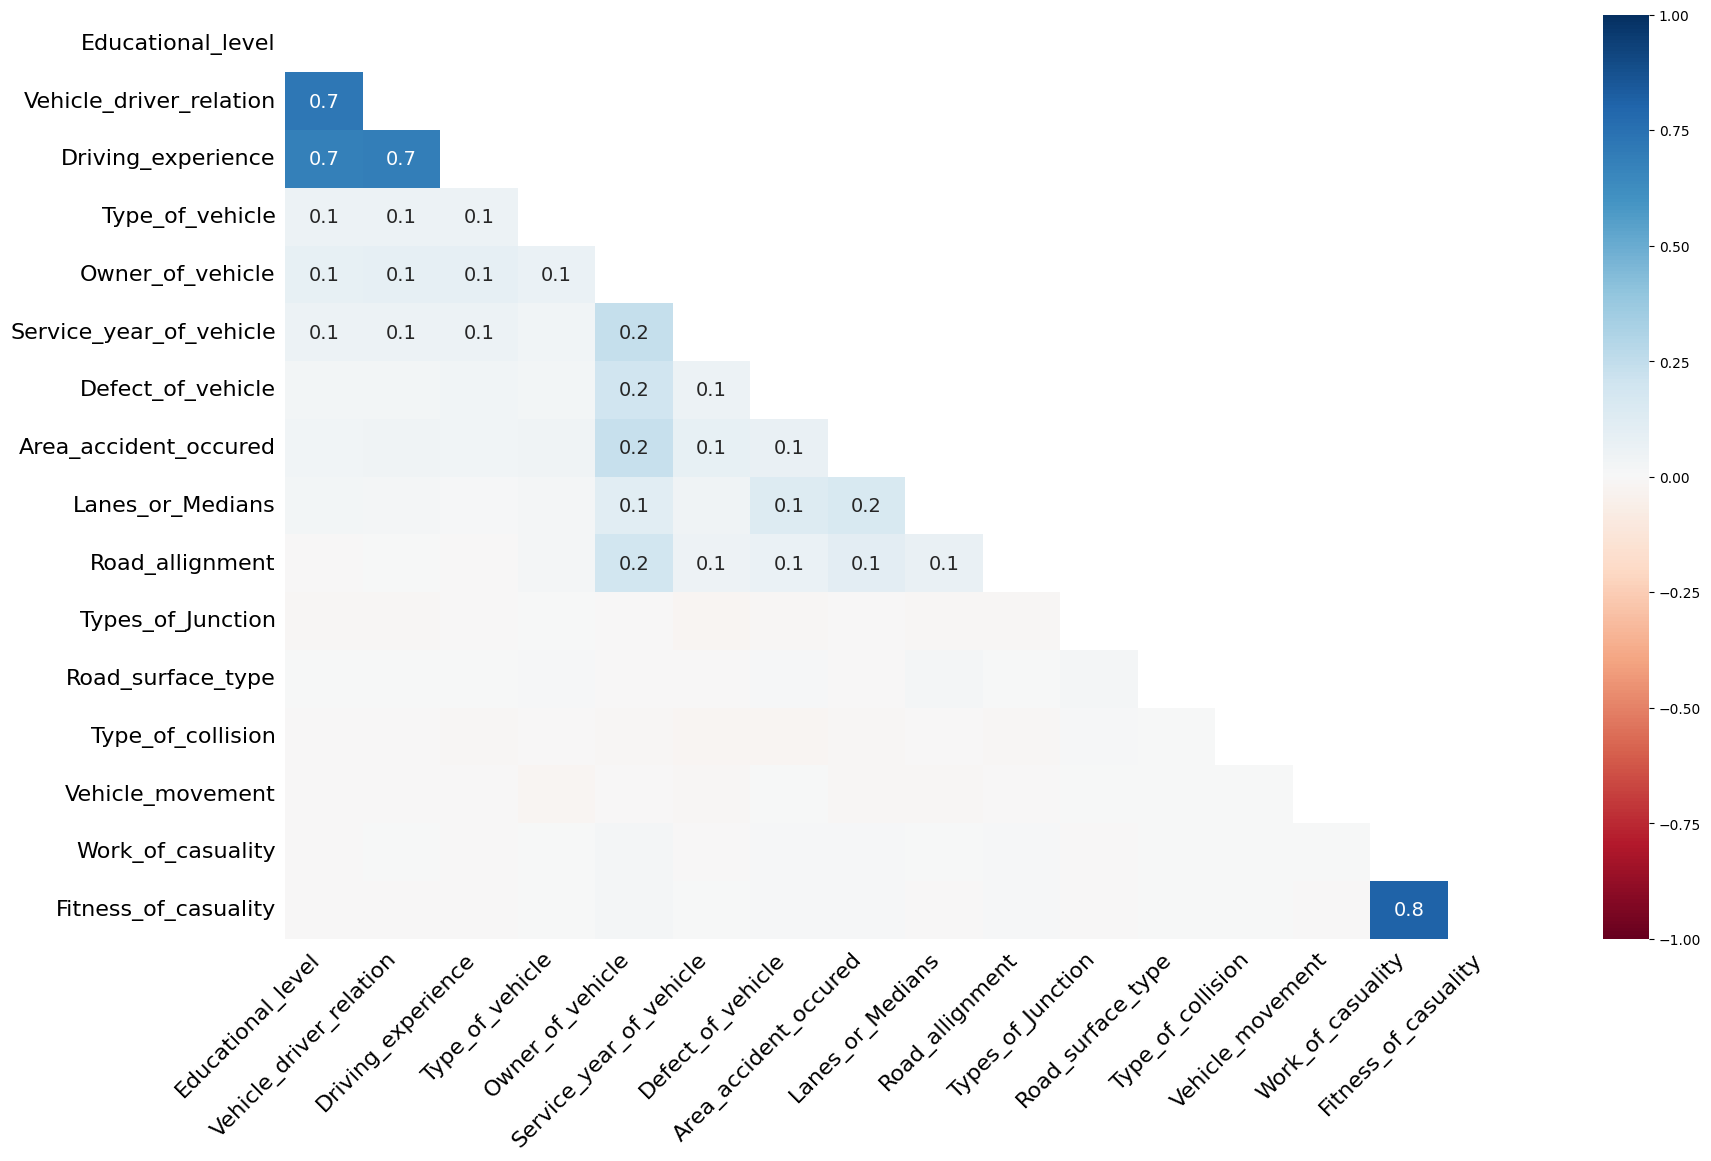

In [44]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()
msno.heatmap(df)
plt.show()

In [45]:
#Remove duplicate rows
df_no_duplicates = df.drop_duplicates()
df_no_duplicates.duplicated().sum()

0

In [ ]:
print(df.info())

In [46]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [ ]:
# Label encoding for categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)


In [47]:
#Categorical Columns: Mode Imputation
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
                       

In [50]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_m

In [ ]:
df.shape

In [51]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
12311    False
12312    False
12313    False
12314    False
12315    False
Length: 12316, dtype: bool

In [53]:
df.groupby('Accident_severity').size()

Accident_severity
Fatal injury        158
Serious Injury     1743
Slight Injury     10415
dtype: int64

In [56]:
class_count = df["Accident_severity"].value_counts()
class_count

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

In [ ]:
df['Accident_Severity'].value_counts().plot(kind='bar')

In [58]:
class_count = dt["Accident_Severity"].value_counts()
class_count

Accident_Severity
3    1280205
2     204504
1      19441
Name: count, dtype: int64

In [60]:
# Label encoding for categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [63]:
# Splitting the dataset
X = df.drop(['Accident_severity'], axis=1)
y = df['Accident_severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(9852, 31) (2464, 31) (9852,) (2464,)


# imbalance SSE

Self_Stacking Ensemble using XGBClassifier Test Accuracy: 0.94

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1448
           1       0.92      0.94      0.93       754
           2       0.93      0.79      0.86       262

    accuracy                           0.94      2464
   macro avg       0.93      0.90      0.92      2464
weighted avg       0.94      0.94      0.94      2464



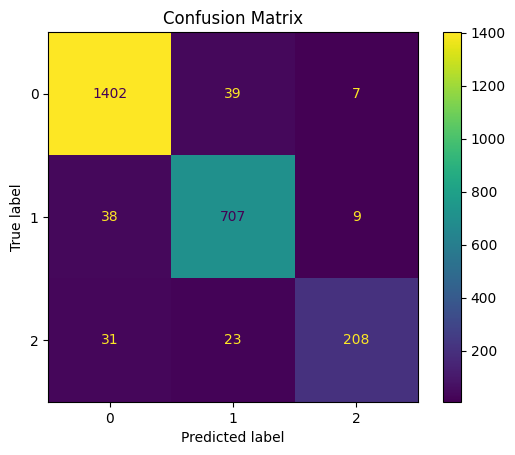

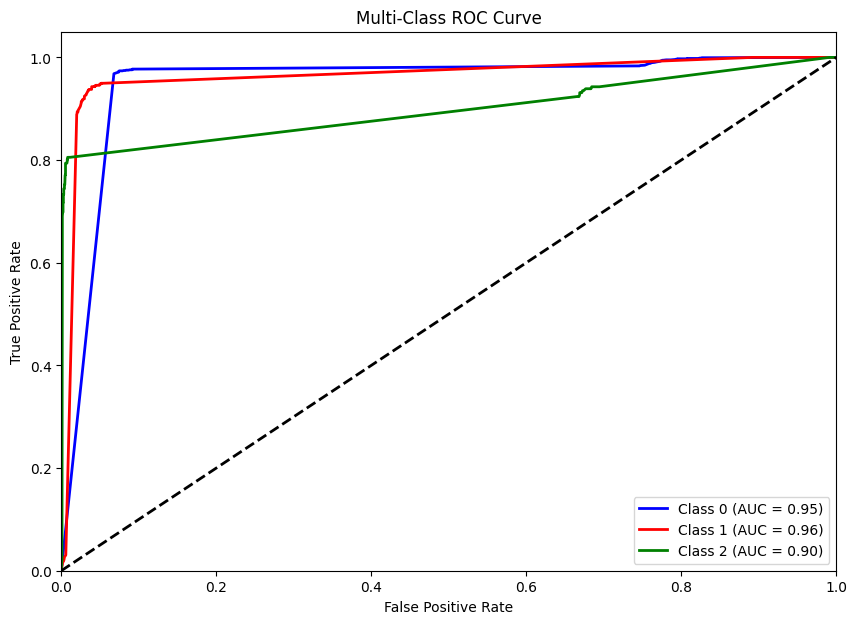

In [66]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt
from itertools import cycle

# Step 1: Generate a synthetic dataset
X, y = make_classification(
    n_samples=12316, n_features=32, n_informative=15, n_redundant=5, 
    n_clusters_per_class=2, weights=[0.6, 0.3, 0.1], n_classes=3, random_state=42
)


# Step 3: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Initialize parameters
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Step 5: Initialize base learners and meta-learner
base_learners = [XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=i) for i in range(k_folds)]
meta_learner = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Step 6: Generate predictions for training the meta-learner
meta_features = np.zeros((len(y_train), k_folds))  # Rows: samples, Columns: base learners
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    # Train the base learner on k-1 folds
    base_learners[fold_idx].fit(X_train_fold, y_train_fold)
    
    # Predict the validation fold and store the predictions
    val_predictions = base_learners[fold_idx].predict(X_val_fold)
    meta_features[val_idx, fold_idx] = val_predictions  # Fill meta-features for this fold

# Step 7: Train the XGBClassifier meta-learner on the aggregated predictions
meta_learner.fit(meta_features, y_train)

# Step 8: Generate predictions on the test set
# Create meta-features for the test set by aggregating predictions from base learners
test_meta_features = np.column_stack([
    base_learner.predict(X_test) for base_learner in base_learners
])
final_predictions = meta_learner.predict(test_meta_features)

# Step 9: Evaluate the stacked model
accuracy = accuracy_score(y_test, final_predictions)
print(f"Self_Stacking Ensemble using XGBClassifier Test Accuracy: {accuracy:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.title("Confusion Matrix")
plt.show()

# Step 10: Plot ROC curve
fpr, tpr, roc_auc = {}, {}, {}
n_classes = len(np.unique(y))
# Binarize the target variable for ROC curve computation
y_test_bin = np.eye(n_classes)[y_test]
final_proba = meta_learner.predict_proba(test_meta_features)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], final_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(10, 7))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])  # Extend as needed for more classes
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

# Plot diagonal line for random guessing
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score

# -------------------------------
# Extra Evaluation Metrics
# -------------------------------
acc  = accuracy_score(y_test, final_predictions)
prec = precision_score(y_test, final_predictions, average='weighted')
rec  = recall_score(y_test, final_predictions, average='weighted')
f1   = f1_score(y_test, final_predictions, average='weighted')

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


Accuracy : 0.9403
Precision: 0.9402
Recall   : 0.9403
F1 Score : 0.9396


# Balance SSE

Self_Stacking Ensemble using XGBClassifier Test Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1479
           1       0.93      0.96      0.95      1438
           2       0.95      0.99      0.97      1501

    accuracy                           0.95      4418
   macro avg       0.95      0.95      0.95      4418
weighted avg       0.95      0.95      0.95      4418



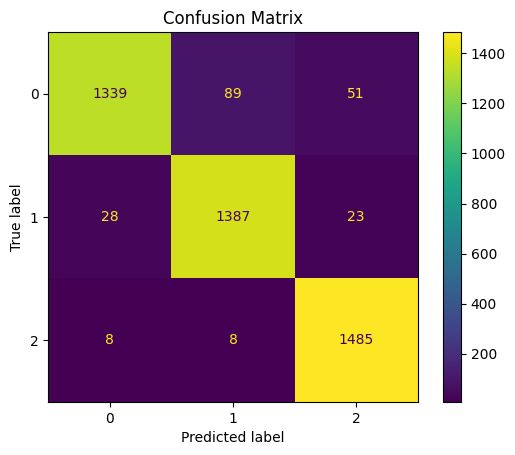

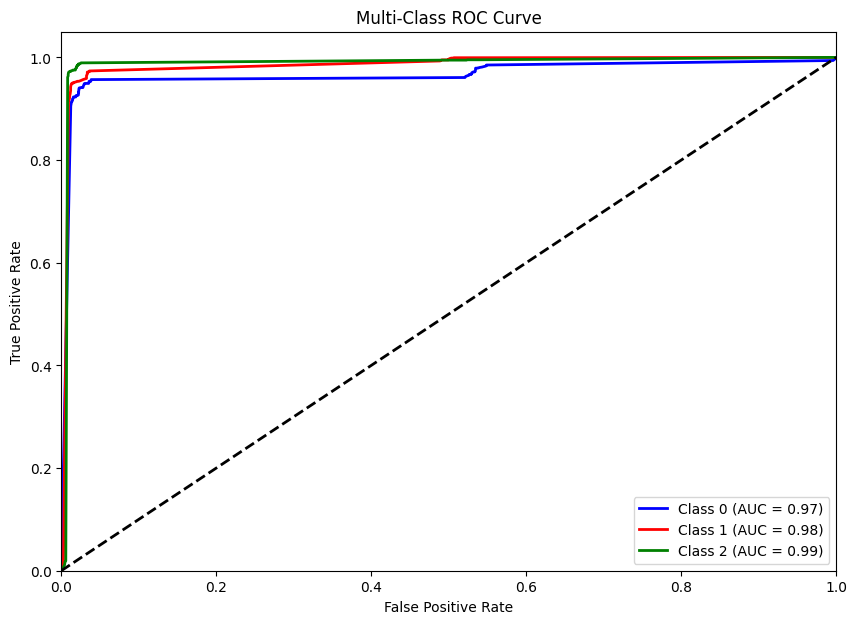

In [68]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt
from itertools import cycle

# Step 1: Generate a synthetic dataset
X, y = make_classification(
    n_samples=12316, n_features=32, n_informative=15, n_redundant=5, 
    n_clusters_per_class=2, weights=[0.6, 0.3, 0.1], n_classes=3, random_state=42
)

# Step 2: Balance the dataset using SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

# Step 3: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Initialize parameters
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Step 5: Initialize base learners and meta-learner
base_learners = [XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=i) for i in range(k_folds)]
meta_learner = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Step 6: Generate predictions for training the meta-learner
meta_features = np.zeros((len(y_train), k_folds))  # Rows: samples, Columns: base learners
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    # Train the base learner on k-1 folds
    base_learners[fold_idx].fit(X_train_fold, y_train_fold)
    
    # Predict the validation fold and store the predictions
    val_predictions = base_learners[fold_idx].predict(X_val_fold)
    meta_features[val_idx, fold_idx] = val_predictions  # Fill meta-features for this fold

# Step 7: Train the XGBClassifier meta-learner on the aggregated predictions
meta_learner.fit(meta_features, y_train)

# Step 8: Generate predictions on the test set
# Create meta-features for the test set by aggregating predictions from base learners
test_meta_features = np.column_stack([
    base_learner.predict(X_test) for base_learner in base_learners
])
final_predictions = meta_learner.predict(test_meta_features)

# Step 9: Evaluate the stacked model
accuracy = accuracy_score(y_test, final_predictions)
print(f"Self_Stacking Ensemble using XGBClassifier Test Accuracy: {accuracy:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.title("Confusion Matrix")
plt.show()

# Step 10: Plot ROC curve
fpr, tpr, roc_auc = {}, {}, {}
n_classes = len(np.unique(y))
# Binarize the target variable for ROC curve computation
y_test_bin = np.eye(n_classes)[y_test]
final_proba = meta_learner.predict_proba(test_meta_features)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], final_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(10, 7))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])  # Extend as needed for more classes
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

# Plot diagonal line for random guessing
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [69]:
from sklearn.metrics import precision_score, recall_score, f1_score

# -------------------------------
# Extra Evaluation Metrics
# -------------------------------
acc  = accuracy_score(y_test, final_predictions)
prec = precision_score(y_test, final_predictions, average='weighted')
rec  = recall_score(y_test, final_predictions, average='weighted')
f1   = f1_score(y_test, final_predictions, average='weighted')

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


Accuracy : 0.9531
Precision: 0.9538
Recall   : 0.9531
F1 Score : 0.9529
